# Customer Segmentation – KMeans Clustering

Analisis segmentasi pelanggan menggunakan KMeans Clustering dengan 7 fitur: Jenis Kelamin, Status, Umur, Pendidikan, Pendapatan, Pekerjaan, dan Wilayah.

In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

# ── 1. Load Data ───────────────────────────────────────────────────────────────
df_raw = pd.read_csv("cleaned_costumer.csv")
print("=== Data Awal ===")
print(df_raw.head())

=== Data Awal ===
   no        penerima jenis_kelamin   status  umur        pendidikan  \
0   1  Mhd Zulkarnain     LAKI-LAKI  Menikah    67  Perguruan Tinggi   
1   2        Subiyani     PEREMPUAN  Sendiri    22           SMA/SMK   
2   3          Rosita     PEREMPUAN  Menikah    49           SMA/SMK   
3   4  Kasmi/Suharman     PEREMPUAN  Menikah    45           SMA/SMK   
4   5  Suriyati Sundu     PEREMPUAN  Menikah    53           SMA/SMK   

   pendapat      pekerjaan               kab/kota kategori_umur  
0      3246  Tidak Bekerja   Kabupaten Purwakarta           Tua  
1      2574     Wiraswasta  Kabupaten Pangandaran          Muda  
2       957  Tidak Bekerja       Kabupaten Subang           Tua  
3      3268     Wiraswasta       Kabupaten Bekasi           Tua  
4      2847     Wiraswasta             Kota Batam           Tua  


## 2. Encoding & Preprocessing

In [2]:
# ── 2. Encoding Otomatis ───────────────────────────────────────────────────────
# Pilih kolom yang digunakan (buang kolom ID, nama, dan duplikat)
kolom_drop = ['no', 'penerima', 'kategori_umur']
df_seg = df_raw.drop(columns=kolom_drop).copy()

# Rename kolom agar rapi
df_seg.rename(columns={
    'jenis_kelamin': 'Jenis_Kelamin',
    'status':        'Status',
    'umur':          'Umur',
    'pendidikan':    'Pendidikan',
    'pendapat':      'Pendapatan',
    'pekerjaan':     'Pekerjaan',
    'kab/kota':      'Wilayah'
}, inplace=True)

# Strip spasi pada semua kolom string
for col in df_seg.select_dtypes(include='object').columns:
    df_seg[col] = df_seg[col].str.strip()

# Perbaiki typo pada nilai kolom Pendidikan
df_seg['Pendidikan'] = df_seg['Pendidikan'].replace('Lainny', 'Lainnya')

# -- Encode Wilayah secara khusus: Kabupaten=0, Kota=1
#    (karena 237 nilai unik, LabelEncoder akan buat angka 0-236 yg tidak bermakna)
df_seg['Wilayah'] = df_seg['Wilayah'].apply(
    lambda x: 0 if str(x).startswith('Kabupaten') else 1
)


# -- Encode kolom string lainnya secara otomatis dengan LabelEncoder
le = LabelEncoder()
kolom_str = df_seg.select_dtypes(include='object').columns
for col in kolom_str:
    df_seg[col] = le.fit_transform(df_seg[col])
    print(f"  Encoding '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n=== Data Setelah Encoding Otomatis ===")
print(df_seg.head())
print("Shape:", df_seg.shape)

  Encoding 'Jenis_Kelamin': {'LAKI-LAKI': np.int64(0), 'PEREMPUAN': np.int64(1)}
  Encoding 'Status': {'Menikah': np.int64(0), 'Sendiri': np.int64(1)}
  Encoding 'Pendidikan': {'Lainnya': np.int64(0), 'Perguruan Tinggi': np.int64(1), 'SMA/SMK': np.int64(2)}
  Encoding 'Pekerjaan': {'Pengusaha': np.int64(0), 'Tidak Bekerja': np.int64(1), 'Wiraswasta': np.int64(2)}

=== Data Setelah Encoding Otomatis ===
   Jenis_Kelamin  Status  Umur  Pendidikan  Pendapatan  Pekerjaan  Wilayah
0              0       0    67           1        3246          1        0
1              1       1    22           2        2574          2        0
2              1       0    49           2         957          1        0
3              1       0    45           2        3268          2        0
4              1       0    53           2        2847          2        1
Shape: (1000, 7)


## 3. Standarisasi & Hierarchical Clustering

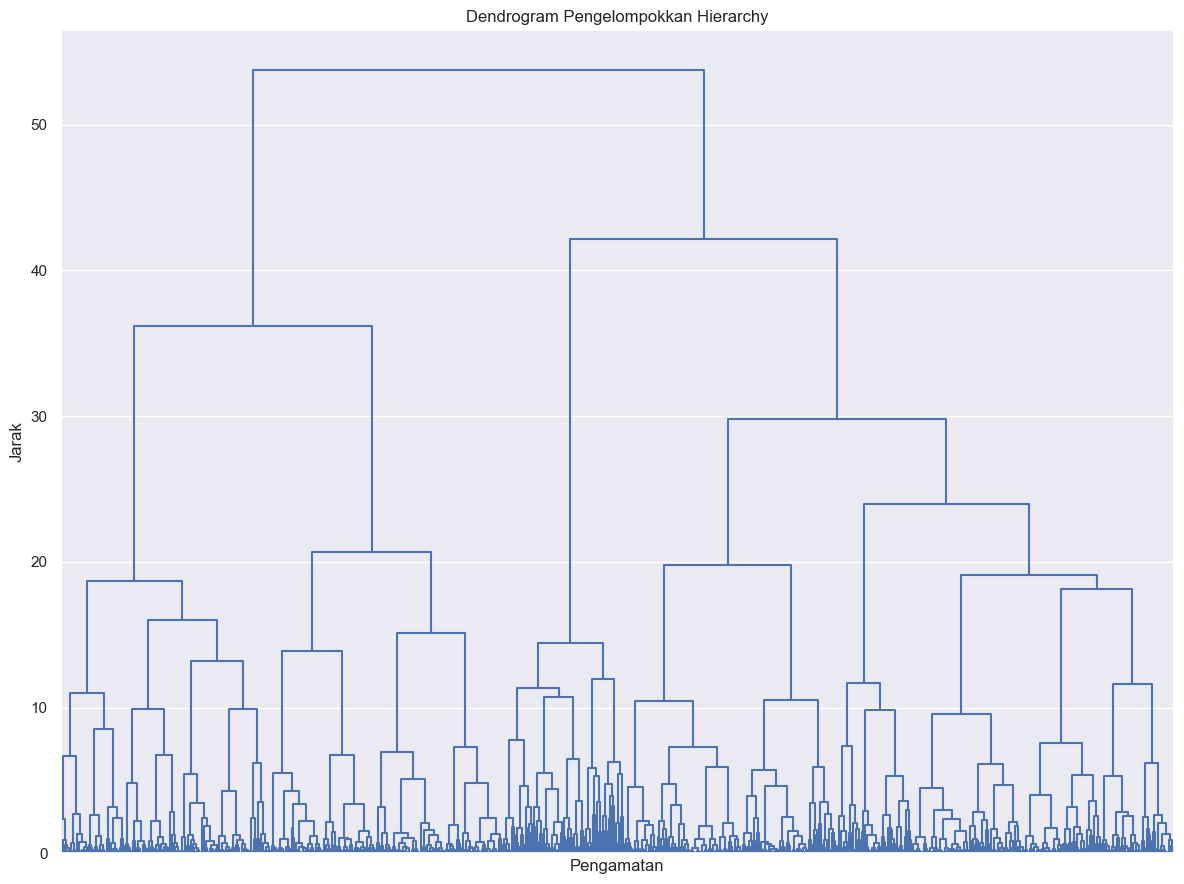

In [3]:
# ── 3. Standarisasi ────────────────────────────────────────────────────────────
scaler = StandardScaler()
seg_std = scaler.fit_transform(df_seg)

# ── 4. Hierarchical Clustering – Dendrogram ───────────────────────────────────
hier_clust = linkage(seg_std, method='ward')

plt.figure(figsize=(12, 9))
plt.title('Dendrogram Pengelompokkan Hierarchy')
plt.xlabel('Pengamatan')
plt.ylabel('Jarak')
dendrogram(hier_clust, show_leaf_counts=False, no_labels=True, color_threshold=0)
plt.tight_layout()
plt.show()

## 4. Elbow Method

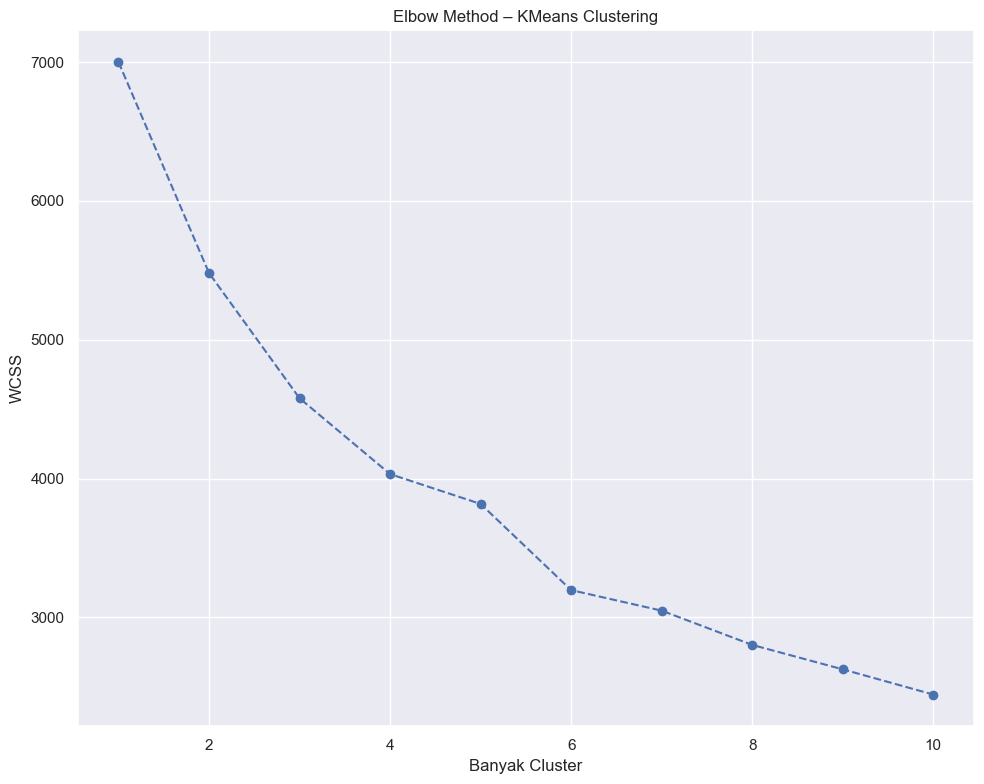

In [4]:
# ── 5. Elbow Method ────────────────────────────────────────────────────────────
wcss = []
for i in range(1, 11):
    kmeans_elbow = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_elbow.fit(seg_std)
    wcss.append(kmeans_elbow.inertia_)

plt.figure(figsize=(10, 8))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method – KMeans Clustering')
plt.xlabel('Banyak Cluster')
plt.ylabel('WCSS')
plt.tight_layout()
plt.show()

## 5. KMeans (k=3) & Heatmap Korelasi

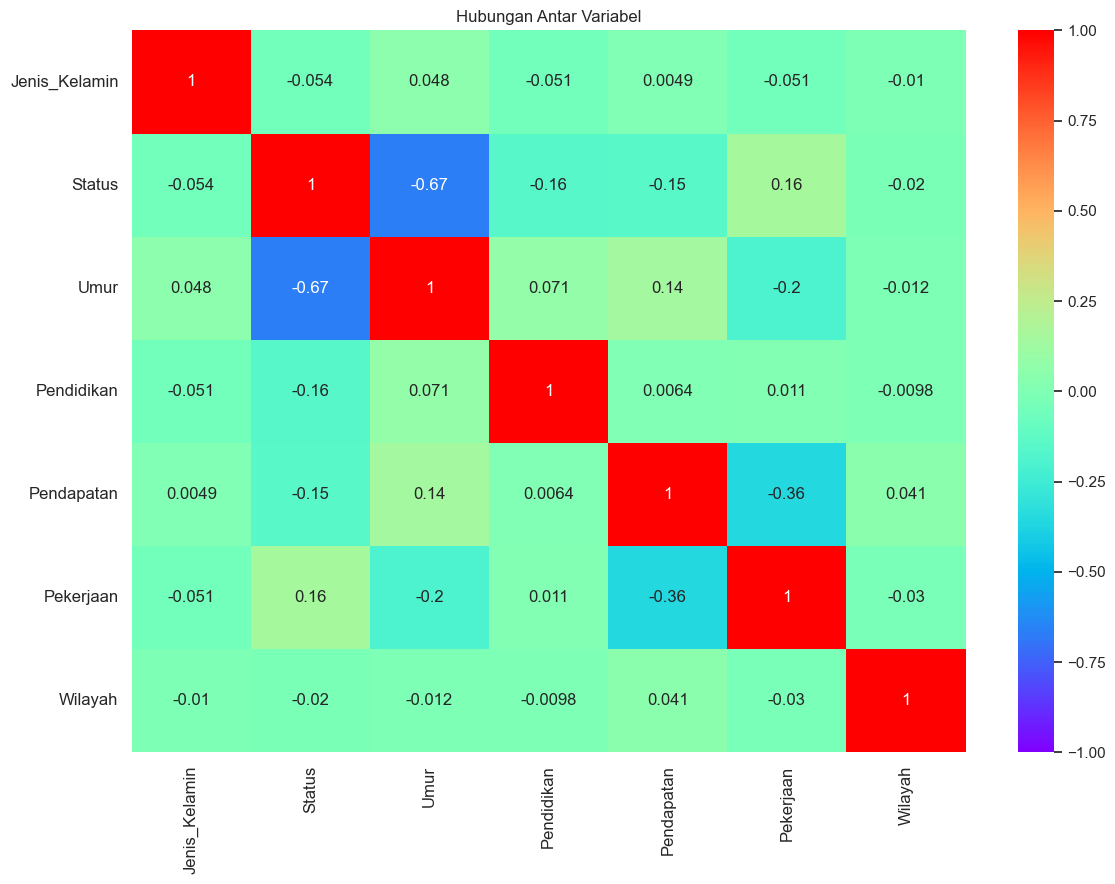

In [5]:
# ── 6. KMeans k=3 ─────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans.fit(seg_std)

# ── 7. Heatmap Korelasi ────────────────────────────────────────────────────────
plt.figure(figsize=(12, 9))
s = sns.heatmap(df_seg.corr(), annot=True, cmap='rainbow', vmin=-1, vmax=1)
s.set_yticklabels(s.get_yticklabels(), rotation=0, fontsize=12)
s.set_xticklabels(s.get_xticklabels(), rotation=90, fontsize=12)
plt.title('Hubungan Antar Variabel')
plt.tight_layout()
plt.show()

## 6. Analisis Segmen

In [6]:
# ── 8. Analisis Segmen ────────────────────────────────────────────────────────
df_seg_kmeans = df_seg.copy()
df_seg_kmeans['Segmentasi K-Means'] = kmeans.labels_

df_seg_analisis = df_seg_kmeans.groupby(['Segmentasi K-Means']).mean()
df_seg_analisis['Jumlah Pengamatan'] = (
    df_seg_kmeans.groupby(['Segmentasi K-Means'])['Umur'].count()
)
df_seg_analisis['Prop Pengamatan'] = (
    df_seg_analisis['Jumlah Pengamatan'] / df_seg_analisis['Jumlah Pengamatan'].sum()
)

print("\n=== Analisis Per Cluster ===")
print(df_seg_analisis)

sorted_idx = df_seg_analisis['Pendapatan'].sort_values().index
label_map = {
    sorted_idx[0]: 'Tidak Konsumtif',
    sorted_idx[1]: 'Konsumtif',
    sorted_idx[2]: 'Milenial'
}

df_seg_analisis = df_seg_analisis.rename(index=label_map)
print("\n=== Segmentasi Final ===")
print(df_seg_analisis)


=== Analisis Per Cluster ===
                    Jenis_Kelamin    Status       Umur  Pendidikan  \
Segmentasi K-Means                                                   
0                        0.601449  0.159420  38.202899    1.500000   
1                        0.517857  0.997024  25.241071    1.255952   
2                        0.555133  0.000000  41.579848    1.538023   

                     Pendapatan  Pekerjaan   Wilayah  Jumlah Pengamatan  \
Segmentasi K-Means                                                        
0                   3585.000000   0.021739  0.608696                138   
1                   1640.303571   1.726190  0.568452                336   
2                   1803.365019   1.680608  0.583650                526   

                    Prop Pengamatan  
Segmentasi K-Means                   
0                             0.138  
1                             0.336  
2                             0.526  

=== Segmentasi Final ===
                    Jenis_K

## 7. Scatter Plot Segmentasi

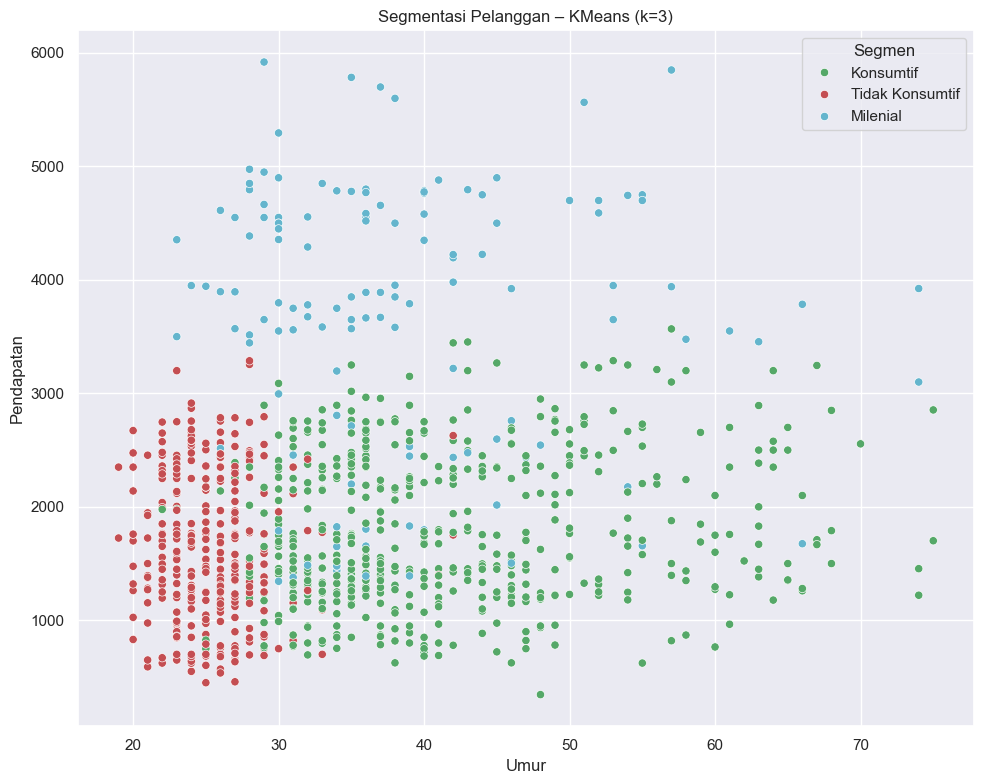

In [7]:
# ── 9. Scatter Plot ────────────────────────────────────────────────────────────
df_seg_kmeans['Labels'] = df_seg_kmeans['Segmentasi K-Means'].map(label_map)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=df_seg_kmeans['Umur'],
    y=df_seg_kmeans['Pendapatan'],
    hue=df_seg_kmeans['Labels'],
    palette=['g', 'r', 'c']
)
plt.title('Segmentasi Pelanggan – KMeans (k=3)')
plt.xlabel('Umur')
plt.ylabel('Pendapatan')
plt.legend(title='Segmen')
plt.tight_layout()
plt.show()

## 8. Radar Chart Profil Segmen

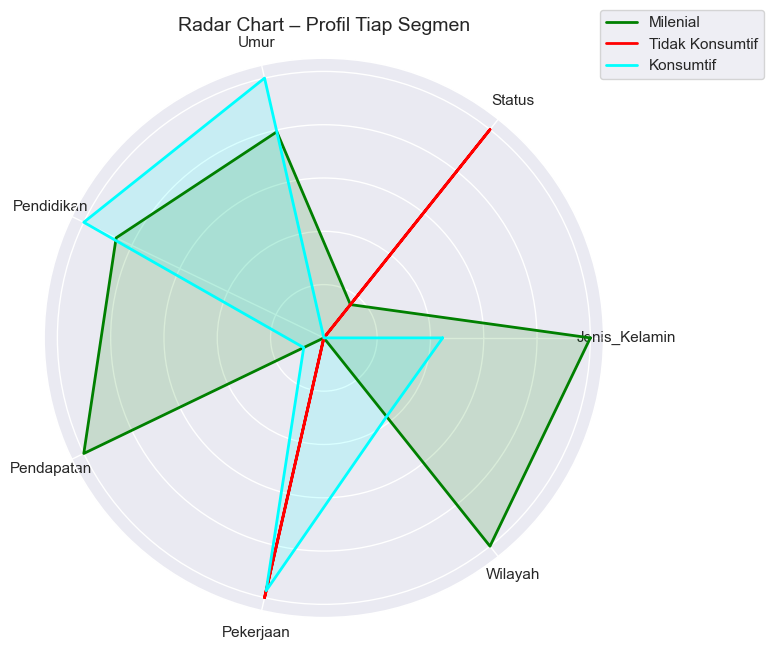

In [8]:
# ── 10. Radar Chart Profil Tiap Segmen ────────────────────────────────────────
import numpy as np

# Ambil kolom fitur untuk radar (exclude kolom hasil analisis)
radar_cols = ['Jenis_Kelamin', 'Status', 'Umur', 'Pendidikan', 'Pendapatan', 'Pekerjaan', 'Wilayah']
radar_data = df_seg_analisis[radar_cols].copy()

# Normalisasi 0-1 agar skala sebanding
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

labels_radar = radar_cols
num_vars = len(labels_radar)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # tutup lingkaran

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['green', 'red', 'cyan']

for i, (segmen, row) in enumerate(radar_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2, label=segmen)
    ax.fill(angles, values, color=colors[i], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_yticklabels([])
ax.set_title('Radar Chart – Profil Tiap Segmen', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 9. Insight Bisnis

In [9]:
# ── 11. Insight Bisnis Otomatis ───────────────────────────────────────────────
print("\n" + "="*60)
print("         INSIGHT BISNIS PER SEGMEN")
print("="*60)

insight_template = {
    'Milenial': {
        'profil': 'Pendapatan tertinggi, aktif bekerja (Wiraswasta/Pengusaha)',
        'strategi': [
            '→ Tawarkan produk/layanan premium dan eksklusif',
            '→ Gunakan platform digital (Instagram, TikTok, e-commerce)',
            '→ Program loyalitas & membership berbasis reward',
            '→ Fokus pada kecepatan layanan dan kemudahan transaksi digital',
        ]
    },
    'Konsumtif': {
        'profil': 'Pendapatan menengah, usia beragam, aktif berbelanja',
        'strategi': [
            '→ Tawarkan promo, diskon, dan bundling produk',
            '→ Manfaatkan email marketing dan push notification',
            '→ Program cicilan atau buy now pay later (BNPL)',
            '→ Cross-selling dan upselling produk terkait',
        ]
    },
    'Tidak Konsumtif': {
        'profil': 'Pendapatan terendah, dominan usia muda, cenderung hemat',
        'strategi': [
            '→ Fokus pada produk harga terjangkau dan value for money',
            '→ Tawarkan program cashback dan voucher hemat',
            '→ Edukasi finansial sebagai strategi engagement jangka panjang',
            '→ Gunakan media sosial organik untuk menjangkau segmen ini',
        ]
    }
}

for segmen, row in df_seg_analisis.iterrows():
    if segmen not in insight_template:
        continue
    info = insight_template[segmen]
    jumlah = int(row['Jumlah Pengamatan'])
    proporsi = row['Prop Pengamatan'] * 100
    rata_pendapatan = row['Pendapatan']
    rata_umur = row['Umur']

    print(f"\n{'─'*60}")
    print(f"  SEGMEN : {segmen.upper()}")
    print(f"  Jumlah : {jumlah} orang ({proporsi:.1f}% dari total)")
    print(f"  Rata-rata Umur      : {rata_umur:.1f} tahun")
    print(f"  Rata-rata Pendapatan: Rp {rata_pendapatan*1000:,.0f}".replace(',', '.'))
    print(f"  Profil  : {info['profil']}")
    print(f"  Rekomendasi Strategi:")
    for s in info['strategi']:
        print(f"    {s}")

print(f"\n{'='*60}")
print("  KESIMPULAN UMUM")
print(f"{'='*60}")
segmen_terbesar = df_seg_analisis['Jumlah Pengamatan'].idxmax()
segmen_terkaya  = df_seg_analisis['Pendapatan'].idxmax()
print(f"  • Segmen terbesar   : {segmen_terbesar} ({int(df_seg_analisis.loc[segmen_terbesar,'Jumlah Pengamatan'])} orang)")
val = df_seg_analisis.loc[segmen_terkaya,'Pendapatan']*1000
print(f"  • Pendapatan tertinggi: {segmen_terkaya} (Rp {val:,.0f})".replace(',','.'))
print(f"  • Total sampel      : {int(df_seg_analisis['Jumlah Pengamatan'].sum())} orang")
print("="*60)


         INSIGHT BISNIS PER SEGMEN

────────────────────────────────────────────────────────────
  SEGMEN : MILENIAL
  Jumlah : 138 orang (13.8% dari total)
  Rata-rata Umur      : 38.2 tahun
  Rata-rata Pendapatan: Rp 3.585.000
  Profil  : Pendapatan tertinggi, aktif bekerja (Wiraswasta/Pengusaha)
  Rekomendasi Strategi:
    → Tawarkan produk/layanan premium dan eksklusif
    → Gunakan platform digital (Instagram, TikTok, e-commerce)
    → Program loyalitas & membership berbasis reward
    → Fokus pada kecepatan layanan dan kemudahan transaksi digital

────────────────────────────────────────────────────────────
  SEGMEN : TIDAK KONSUMTIF
  Jumlah : 336 orang (33.6% dari total)
  Rata-rata Umur      : 25.2 tahun
  Rata-rata Pendapatan: Rp 1.640.304
  Profil  : Pendapatan terendah, dominan usia muda, cenderung hemat
  Rekomendasi Strategi:
    → Fokus pada produk harga terjangkau dan value for money
    → Tawarkan program cashback dan voucher hemat
    → Edukasi finansial sebagai stra

## 10. Dashboard Visualisasi & Box Plot

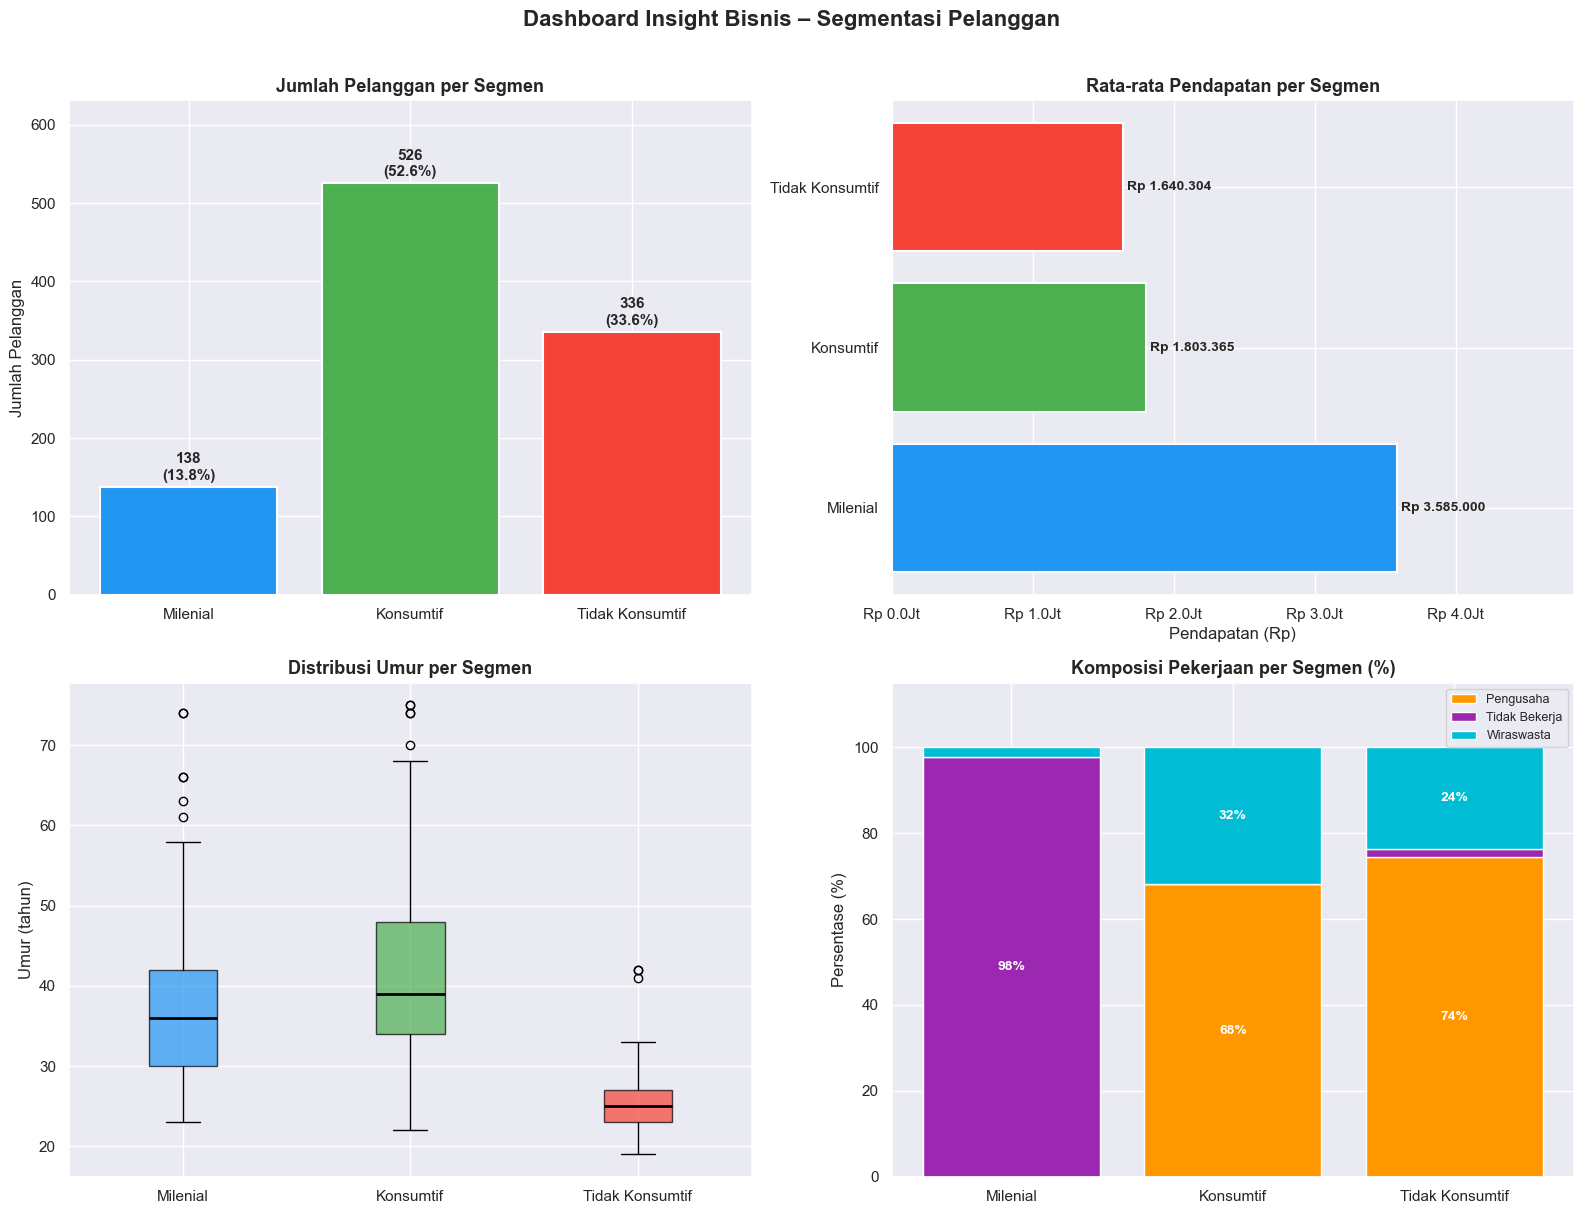

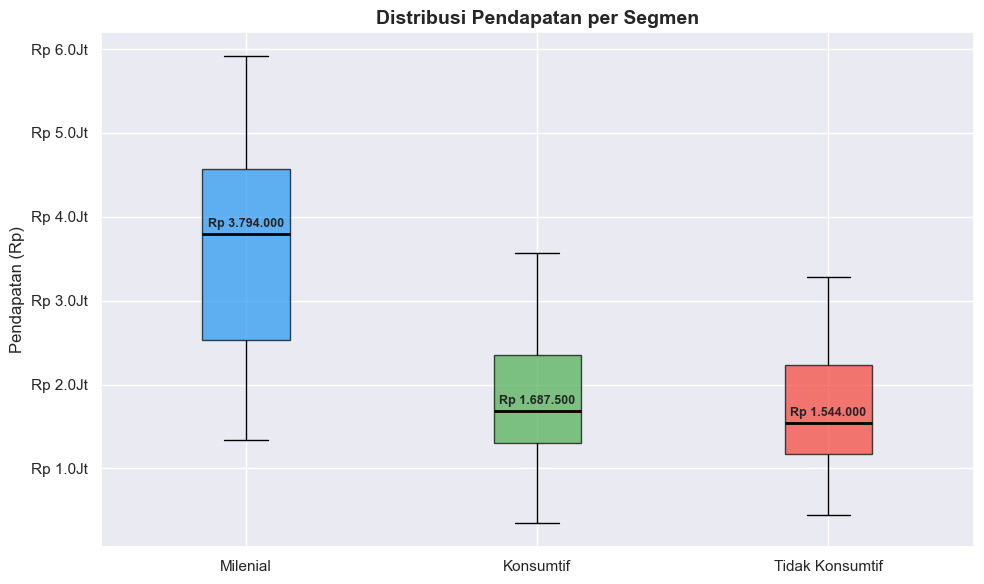

In [10]:

import numpy as np

# ── 12. Dashboard Insight Bisnis (4 chart dalam 1 figure) ─────────────────────
palette_segmen = {'Milenial': '#2196F3', 'Konsumtif': '#4CAF50', 'Tidak Konsumtif': '#F44336'}
segmen_order   = ['Milenial', 'Konsumtif', 'Tidak Konsumtif']
colors_list    = [palette_segmen[s] for s in segmen_order]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dashboard Insight Bisnis – Segmentasi Pelanggan', fontsize=16, fontweight='bold', y=1.01)

# ── Chart 1: Jumlah & Proporsi per Segmen (Bar) ───────────────────────────────
ax1 = axes[0, 0]
jumlah_vals = [df_seg_analisis.loc[s, 'Jumlah Pengamatan'] for s in segmen_order]
bars = ax1.bar(segmen_order, jumlah_vals, color=colors_list, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, jumlah_vals):
    pct = val / sum(jumlah_vals) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{int(val)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Jumlah Pelanggan per Segmen', fontsize=13, fontweight='bold')
ax1.set_ylabel('Jumlah Pelanggan')
ax1.set_ylim(0, max(jumlah_vals) * 1.2)
ax1.tick_params(axis='x', labelsize=11)

# ── Chart 2: Rata-rata Pendapatan per Segmen (Bar horizontal) ─────────────────
ax2 = axes[0, 1]
pendapatan_vals = [df_seg_analisis.loc[s, 'Pendapatan'] * 1000 for s in segmen_order]
bars2 = ax2.barh(segmen_order, pendapatan_vals, color=colors_list, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, pendapatan_vals):
    ax2.text(val + 30000, bar.get_y() + bar.get_height()/2,
             f'Rp {val:,.0f}'.replace(',', '.'), va='center', fontsize=10, fontweight='bold')
ax2.set_title('Rata-rata Pendapatan per Segmen', fontsize=13, fontweight='bold')
ax2.set_xlabel('Pendapatan (Rp)')
ax2.set_xlim(0, max(pendapatan_vals) * 1.35)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}Jt'))

# ── Chart 3: Box Plot Distribusi Umur per Segmen ──────────────────────────────
ax3 = axes[1, 0]
data_box = [df_seg_kmeans[df_seg_kmeans['Labels'] == s]['Umur'].values for s in segmen_order]
bp = ax3.boxplot(data_box, patch_artist=True, tick_labels=segmen_order,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_title('Distribusi Umur per Segmen', fontsize=13, fontweight='bold')
ax3.set_ylabel('Umur (tahun)')
ax3.tick_params(axis='x', labelsize=11)

# ── Chart 4: Stacked Bar Komposisi Pekerjaan per Segmen ───────────────────────
ax4 = axes[1, 1]
pekerjaan_map = {0: 'Tidak Bekerja', 1: 'Wiraswasta', 2: 'Pengusaha'}
df_pek = df_seg_kmeans.copy()
df_pek['Pekerjaan_Label'] = df_pek['Pekerjaan'].map(pekerjaan_map)
df_pek_pct = (df_pek.groupby(['Labels', 'Pekerjaan_Label'])
                     .size()
                     .unstack(fill_value=0))
df_pek_pct = df_pek_pct.div(df_pek_pct.sum(axis=1), axis=0) * 100
df_pek_pct = df_pek_pct.reindex(segmen_order)

pek_colors = ['#FF9800', '#9C27B0', '#00BCD4']
bottom = np.zeros(len(segmen_order))
for j, (pek, color) in enumerate(zip(df_pek_pct.columns, pek_colors)):
    vals = df_pek_pct[pek].values
    bars4 = ax4.bar(segmen_order, vals, bottom=bottom, label=pek, color=color, edgecolor='white')
    for bar, val in zip(bars4, vals):
        if val > 5:
            ax4.text(bar.get_x() + bar.get_width()/2,
                     bar.get_y() + bar.get_height()/2,
                     f'{val:.0f}%', ha='center', va='center', fontsize=10,
                     color='white', fontweight='bold')
    bottom += vals
ax4.set_title('Komposisi Pekerjaan per Segmen (%)', fontsize=13, fontweight='bold')
ax4.set_ylabel('Persentase (%)')
ax4.set_ylim(0, 115)
ax4.legend(loc='upper right', fontsize=9)
ax4.tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.show()

# ── 13. Box Plot Pendapatan per Segmen (terpisah, lebih detail) ───────────────
fig2, ax = plt.subplots(figsize=(10, 6))
data_pend = [df_seg_kmeans[df_seg_kmeans['Labels'] == s]['Pendapatan'].values * 1000
             for s in segmen_order]
bp2 = ax.boxplot(data_pend, patch_artist=True, tick_labels=segmen_order,
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch, color in zip(bp2['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
# Tambahkan nilai median di atas box
for i, data in enumerate(data_pend):
    median = np.median(data)
    ax.text(i + 1, median + 50000, f'Rp {median:,.0f}'.replace(',', '.'),
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Distribusi Pendapatan per Segmen', fontsize=14, fontweight='bold')
ax.set_ylabel('Pendapatan (Rp)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}Jt'))
plt.tight_layout()
plt.show()
